<a href="https://colab.research.google.com/github/nihemelandu/clickstream-purchase-intent/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Cell 1 — Mount Google Drive and verify file access

from google.colab import drive
drive.mount('/content/drive')

import os

# Define file paths
BASE_PATH = '/content/drive/My Drive/'
FILES = {
    'oct': os.path.join(BASE_PATH, '2019-Oct.csv'),
    'nov': os.path.join(BASE_PATH, '2019-Nov.csv')
}

# Verify files exist and check sizes
for name, path in FILES.items():
    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{name}: {path}")
        print(f"  Size: {size_gb:.2f} GB")
        print(f"  Exists: True\n")
    else:
        print(f"{name}: FILE NOT FOUND at {path}\n")

Mounted at /content/drive
oct: /content/drive/My Drive/2019-Oct.csv
  Size: 5.28 GB
  Exists: True

nov: /content/drive/My Drive/2019-Nov.csv
  Size: 8.39 GB
  Exists: True



In [3]:
# Cell 2 — Install DuckDB and import libraries

!pip install duckdb -q

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Connect to DuckDB — in-memory analytical database
con = duckdb.connect()

# Verify DuckDB version
print(f"DuckDB version: {duckdb.__version__}")
print(f"Pandas version: {pd.__version__}")
print("All libraries imported successfully")

DuckDB version: 1.3.2
Pandas version: 2.2.2
All libraries imported successfully


In [4]:
# Cell 3 — Initial data inspection

# Inspect schema and first few rows of October file
print("=" * 60)
print("OCTOBER 2019 — SCHEMA AND SAMPLE ROWS")
print("=" * 60)

oct_sample = con.execute("""
    SELECT *
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = 10000
    )
    LIMIT 5
""").df()

print(oct_sample.to_string())
print(f"\nColumn names: {list(oct_sample.columns)}")
print(f"Data types:\n{oct_sample.dtypes}")

# Inspect schema and first few rows of November file
print("\n" + "=" * 60)
print("NOVEMBER 2019 — SCHEMA AND SAMPLE ROWS")
print("=" * 60)

nov_sample = con.execute("""
    SELECT *
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = 10000
    )
    LIMIT 5
""").df()

print(nov_sample.to_string())
print(f"\nColumn names: {list(nov_sample.columns)}")
print(f"Data types:\n{nov_sample.dtypes}")

# Confirm schemas match between the two files
oct_cols = list(oct_sample.columns)
nov_cols = list(nov_sample.columns)

print("\n" + "=" * 60)
print("SCHEMA CONSISTENCY CHECK")
print("=" * 60)
if oct_cols == nov_cols:
    print("✓ Both files have identical column names and order")
else:
    print("⚠ Column mismatch between files")
    print(f"  October columns:  {oct_cols}")
    print(f"  November columns: {nov_cols}")

OCTOBER 2019 — SCHEMA AND SAMPLE ROWS
           event_time event_type  product_id          category_id                        category_code     brand     price    user_id                          user_session
0 2019-10-01 00:00:00       view    44600062  2103807459595387724                                 None  shiseido   35.7900  541312140  72d76fde-8bb3-4e00-8c23-a032dfed738c
1 2019-10-01 00:00:00       view     3900821  2053013552326770905  appliances.environment.water_heater      aqua   33.2000  554748717  9333dfbd-b87a-4708-9857-6336556b0fcc
2 2019-10-01 00:00:01       view    17200506  2053013559792632471           furniture.living_room.sofa      None  543.1000  519107250  566511c2-e2e3-422b-b695-cf8e6e792ca8
3 2019-10-01 00:00:01       view     1307067  2053013558920217191                   computers.notebook    lenovo  251.7400  550050854  7c90fc70-0e80-4590-96f3-13c02c18c713
4 2019-10-01 00:00:04       view     1004237  2053013555631882655               electronics.smartphone

ROW COUNTS PER FILE


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

October 2019:       42,448,764 rows
November 2019:      67,501,979 rows
Combined:          109,950,743 rows

November is 1.59x larger than October

EVENT TYPE DISTRIBUTION — OCTOBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type    count  percentage
      view 40779399     96.0700
      cart   926516      2.1800
  purchase   742849      1.7500

EVENT TYPE DISTRIBUTION — NOVEMBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type    count  percentage
      view 63556110     94.1500
      cart  3028930      4.4900
  purchase   916939      1.3600

EVENT TYPE DISTRIBUTION — COMBINED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type     count  percentage
      view 104335509     94.8900
      cart   3955446      3.6000
  purchase   1659788      1.5100


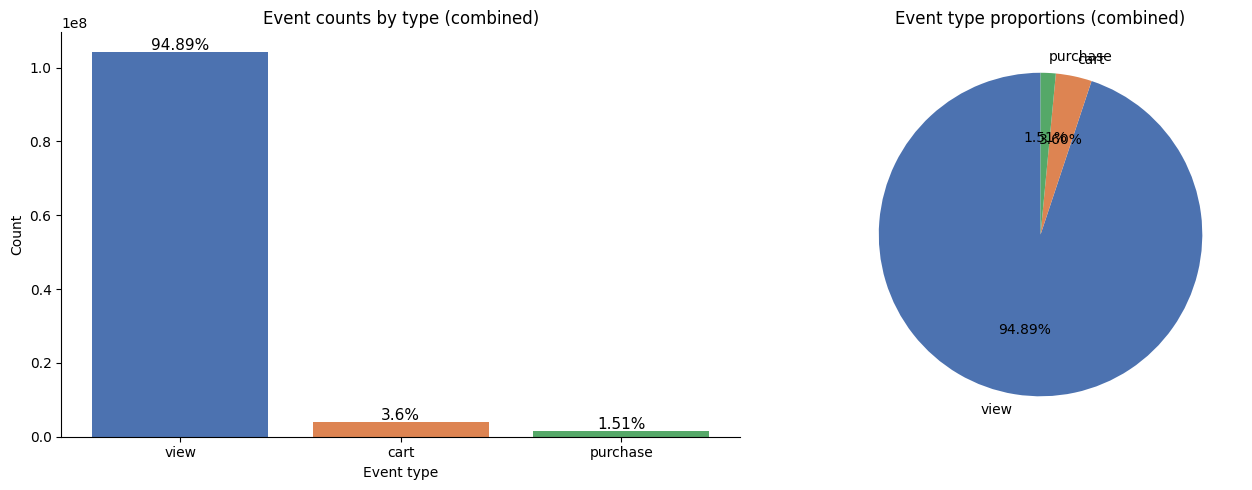


Chart saved as event_distribution.png


In [5]:
# Cell 4 — Row counts and combined volume

print("=" * 60)
print("ROW COUNTS PER FILE")
print("=" * 60)

oct_count = con.execute("""
    SELECT COUNT(*) as row_count
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = -1
    )
""").df()

nov_count = con.execute("""
    SELECT COUNT(*) as row_count
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = -1
    )
""").df()

oct_rows = oct_count['row_count'].values[0]
nov_rows = nov_count['row_count'].values[0]
total_rows = oct_rows + nov_rows

print(f"October 2019:  {oct_rows:>15,.0f} rows")
print(f"November 2019: {nov_rows:>15,.0f} rows")
print(f"Combined:      {total_rows:>15,.0f} rows")
print(f"\nNovember is {(nov_rows / oct_rows):.2f}x larger than October")

print("\n" + "=" * 60)
print("EVENT TYPE DISTRIBUTION — OCTOBER")
print("=" * 60)

oct_events = con.execute("""
    SELECT
        event_type,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = -1
    )
    GROUP BY event_type
    ORDER BY count DESC
""").df()

print(oct_events.to_string(index=False))

print("\n" + "=" * 60)
print("EVENT TYPE DISTRIBUTION — NOVEMBER")
print("=" * 60)

nov_events = con.execute("""
    SELECT
        event_type,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = -1
    )
    GROUP BY event_type
    ORDER BY count DESC
""").df()

print(nov_events.to_string(index=False))

print("\n" + "=" * 60)
print("EVENT TYPE DISTRIBUTION — COMBINED")
print("=" * 60)

combined_events = con.execute("""
    SELECT
        event_type,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM (
        SELECT event_type FROM read_csv_auto(
            '/content/drive/My Drive/2019-Oct.csv',
            sample_size = -1
        )
        UNION ALL
        SELECT event_type FROM read_csv_auto(
            '/content/drive/My Drive/2019-Nov.csv',
            sample_size = -1
        )
    )
    GROUP BY event_type
    ORDER BY count DESC
""").df()

print(combined_events.to_string(index=False))

# Visualise combined event distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868']

# Bar chart
axes[0].bar(
    combined_events['event_type'],
    combined_events['count'],
    color=colors
)
axes[0].set_title('Event counts by type (combined)')
axes[0].set_xlabel('Event type')
axes[0].set_ylabel('Count')
for i, (count, pct) in enumerate(
    zip(combined_events['count'], combined_events['percentage'])
):
    axes[0].text(
        i, count + total_rows * 0.005,
        f'{pct}%',
        ha='center', fontsize=11
    )

# Pie chart
axes[1].pie(
    combined_events['count'],
    labels=combined_events['event_type'],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90
)
axes[1].set_title('Event type proportions (combined)')

plt.tight_layout()
plt.savefig('event_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as event_distribution.png")

MISSING VALUE ANALYSIS — OCTOBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

            feature         count  percentage
   event_time_nulls        0.0000      0.0000
   event_type_nulls        0.0000      0.0000
   product_id_nulls        0.0000      0.0000
  category_id_nulls        0.0000      0.0000
category_code_nulls 13515609.0000     31.8400
        brand_nulls  6113008.0000     14.4000
        price_nulls        0.0000      0.0000
      user_id_nulls        0.0000      0.0000
 user_session_nulls        2.0000      0.0000

MISSING VALUE ANALYSIS — NOVEMBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

            feature         count  percentage
   event_time_nulls        0.0000      0.0000
   event_type_nulls        0.0000      0.0000
   product_id_nulls        0.0000      0.0000
  category_id_nulls        0.0000      0.0000
category_code_nulls 21898171.0000     32.4400
        brand_nulls  9218235.0000     13.6600
        price_nulls        0.0000      0.0000
      user_id_nulls        0.0000      0.0000
 user_session_nulls       10.0000      0.0000

MISSING VALUE SUMMARY — COMBINED
            feature         count  percentage
   event_time_nulls        0.0000      0.0000
   event_type_nulls        0.0000      0.0000
   product_id_nulls        0.0000      0.0000
  category_id_nulls        0.0000      0.0000
category_code_nulls 35413780.0000     32.2100
        brand_nulls 15331243.0000     13.9400
        price_nulls        0.0000      0.0000
      user_id_nulls        0.0000      0.0000
 user_session_nulls       12.0000      0.0000


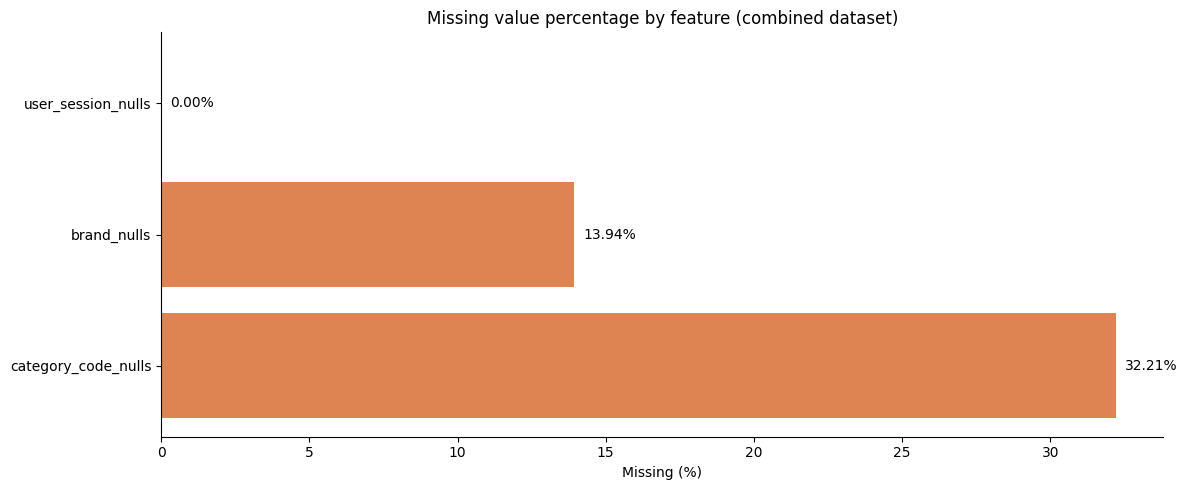


Chart saved as missing_values.png


In [6]:
# Cell 5 — Missing value analysis

print("=" * 60)
print("MISSING VALUE ANALYSIS — OCTOBER")
print("=" * 60)

oct_missing = con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN event_time IS NULL THEN 1 ELSE 0 END) as event_time_nulls,
        SUM(CASE WHEN event_type IS NULL THEN 1 ELSE 0 END) as event_type_nulls,
        SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) as product_id_nulls,
        SUM(CASE WHEN category_id IS NULL THEN 1 ELSE 0 END) as category_id_nulls,
        SUM(CASE WHEN category_code IS NULL THEN 1 ELSE 0 END) as category_code_nulls,
        SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END) as brand_nulls,
        SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) as price_nulls,
        SUM(CASE WHEN user_id IS NULL THEN 1 ELSE 0 END) as user_id_nulls,
        SUM(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) as user_session_nulls
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = -1
    )
""").df()

# Reshape for readability
oct_missing_t = oct_missing.T.reset_index()
oct_missing_t.columns = ['feature', 'count']
oct_missing_t['percentage'] = (
    oct_missing_t['count'] / oct_rows * 100
).round(2)
oct_missing_t = oct_missing_t[oct_missing_t['feature'] != 'total_rows']

print(oct_missing_t.to_string(index=False))

print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS — NOVEMBER")
print("=" * 60)

nov_missing = con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN event_time IS NULL THEN 1 ELSE 0 END) as event_time_nulls,
        SUM(CASE WHEN event_type IS NULL THEN 1 ELSE 0 END) as event_type_nulls,
        SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) as product_id_nulls,
        SUM(CASE WHEN category_id IS NULL THEN 1 ELSE 0 END) as category_id_nulls,
        SUM(CASE WHEN category_code IS NULL THEN 1 ELSE 0 END) as category_code_nulls,
        SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END) as brand_nulls,
        SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) as price_nulls,
        SUM(CASE WHEN user_id IS NULL THEN 1 ELSE 0 END) as user_id_nulls,
        SUM(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) as user_session_nulls
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = -1
    )
""").df()

nov_missing_t = nov_missing.T.reset_index()
nov_missing_t.columns = ['feature', 'count']
nov_missing_t['percentage'] = (
    nov_missing_t['count'] / nov_rows * 100
).round(2)
nov_missing_t = nov_missing_t[nov_missing_t['feature'] != 'total_rows']

print(nov_missing_t.to_string(index=False))

print("\n" + "=" * 60)
print("MISSING VALUE SUMMARY — COMBINED")
print("=" * 60)

combined_missing = oct_missing_t.copy()
combined_missing['count'] = oct_missing_t['count'] + nov_missing_t['count']
combined_missing['percentage'] = (
    combined_missing['count'] / total_rows * 100
).round(2)

print(combined_missing.to_string(index=False))

# Visualise missing values
fig, ax = plt.subplots(figsize=(12, 5))

features_with_missing = combined_missing[combined_missing['count'] > 0]

bars = ax.barh(
    features_with_missing['feature'],
    features_with_missing['percentage'],
    color=['#DD8452' if p > 10 else '#4C72B0'
           for p in features_with_missing['percentage']]
)

ax.set_xlabel('Missing (%)')
ax.set_title('Missing value percentage by feature (combined dataset)')

for bar, pct in zip(
    bars,
    features_with_missing['percentage']
):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.2f}%',
        va='center'
    )

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as missing_values.png")

In [7]:
# Cell 5b — One-time conversion of CSV files to Parquet
# Run once — skip on subsequent sessions if Parquet files exist

import os

OCT = '/content/drive/My Drive/2019-Oct.csv'
NOV = '/content/drive/My Drive/2019-Nov.csv'
OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'

# Redefine constants
oct_rows = 42_448_764
nov_rows = 67_501_979
total_rows = oct_rows + nov_rows

con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

if not os.path.exists(OCT_PARQUET):
    print("Converting October CSV to Parquet...")
    con.execute(f"""
        COPY (
            SELECT * FROM read_csv_auto('{OCT}', sample_size=-1)
        ) TO '{OCT_PARQUET}'
        (FORMAT PARQUET, COMPRESSION SNAPPY)
    """)
    size = os.path.getsize(OCT_PARQUET) / (1024**3)
    print(f"October Parquet saved: {size:.2f} GB")
else:
    print("October Parquet already exists — skipping conversion")

if not os.path.exists(NOV_PARQUET):
    print("Converting November CSV to Parquet...")
    con.execute(f"""
        COPY (
            SELECT * FROM read_csv_auto('{NOV}', sample_size=-1)
        ) TO '{NOV_PARQUET}'
        (FORMAT PARQUET, COMPRESSION SNAPPY)
    """)
    size = os.path.getsize(NOV_PARQUET) / (1024**3)
    print(f"November Parquet saved: {size:.2f} GB")
else:
    print("November Parquet already exists — skipping conversion")

print("\nParquet conversion complete")
print("All subsequent queries will read from Parquet files")

Converting October CSV to Parquet...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

October Parquet saved: 1.61 GB
Converting November CSV to Parquet...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

November Parquet saved: 2.83 GB

Parquet conversion complete
All subsequent queries will read from Parquet files


Once the Parquet files exist, update the file path constants at the top of every subsequent cell

In [8]:
# Constants — add to top of every cell after conversion
OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
oct_rows = 42_448_764
nov_rows = 67_501_979
total_rows = oct_rows + nov_rows
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

In [10]:
# Cell 6 — Session-level statistics (memory-optimised)

import gc
import matplotlib.pyplot as plt

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
oct_rows = 42_448_764
nov_rows = 67_501_979
total_rows = oct_rows + nov_rows
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("SESSION-LEVEL STATISTICS — OCTOBER (memory-safe)")
print("=" * 60)

oct_sessions = con.execute(f"""
    SELECT
        COUNT(DISTINCT user_session) as total_sessions,
        SUM(has_purchase) as purchase_sessions,
        ROUND(AVG(event_count), 2) as mean_events,
        APPROX_QUANTILE(event_count, 0.5) as median_events,
        MAX(event_count) as max_events,
        ROUND(AVG(session_duration_secs), 2) as mean_duration_secs,
        APPROX_QUANTILE(session_duration_secs, 0.5)
            as median_duration_secs,
        ROUND(AVG(view_count), 2) as mean_views,
        ROUND(AVG(cart_count), 4) as mean_carts,
        ROUND(AVG(product_count), 2) as mean_products
    FROM (
        SELECT
            user_session,
            COUNT(*) as event_count,
            APPROX_COUNT_DISTINCT(product_id) as product_count,
            SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END)
                as cart_count,
            SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END)
                as view_count,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase,
            EPOCH(MAX(event_time)) - EPOCH(MIN(event_time))
                as session_duration_secs
        FROM parquet_scan('{OCT_PARQUET}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
""").df()

print(oct_sessions.T.to_string(header=False))

del oct_sessions
gc.collect()

print("\n" + "=" * 60)
print("SESSION-LEVEL STATISTICS — NOVEMBER (memory-safe)")
print("=" * 60)

nov_sessions = con.execute(f"""
    SELECT
        COUNT(DISTINCT user_session) as total_sessions,
        SUM(has_purchase) as purchase_sessions,
        ROUND(AVG(event_count), 2) as mean_events,
        APPROX_QUANTILE(event_count, 0.5) as median_events,
        MAX(event_count) as max_events,
        ROUND(AVG(session_duration_secs), 2) as mean_duration_secs,
        APPROX_QUANTILE(session_duration_secs, 0.5)
            as median_duration_secs,
        ROUND(AVG(view_count), 2) as mean_views,
        ROUND(AVG(cart_count), 4) as mean_carts,
        ROUND(AVG(product_count), 2) as mean_products
    FROM (
        SELECT
            user_session,
            COUNT(*) as event_count,
            APPROX_COUNT_DISTINCT(product_id) as product_count,
            SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END)
                as cart_count,
            SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END)
                as view_count,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase,
            EPOCH(MAX(event_time)) - EPOCH(MIN(event_time))
                as session_duration_secs
        FROM parquet_scan('{NOV_PARQUET}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
""").df()

print(nov_sessions.T.to_string(header=False))

del nov_sessions
gc.collect()

print("\n" + "=" * 60)
print("SESSION OUTCOME — COMBINED")
print("=" * 60)

# Fix: compute has_purchase at session level first,
# then aggregate — avoids nested aggregate error
session_outcome = con.execute(f"""
    WITH oct_sessions AS (
        SELECT
            user_session,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase
        FROM parquet_scan('{OCT_PARQUET}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    ),
    nov_sessions AS (
        SELECT
            user_session,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase
        FROM parquet_scan('{NOV_PARQUET}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    ),
    combined AS (
        SELECT * FROM oct_sessions
        UNION ALL
        SELECT * FROM nov_sessions
    )
    SELECT
        COUNT(*) as total_sessions,
        SUM(has_purchase) as sessions_with_purchase,
        COUNT(*) - SUM(has_purchase) as sessions_without_purchase,
        ROUND(SUM(has_purchase) * 100.0 / COUNT(*), 2)
            as purchase_rate_pct
    FROM combined
""").df()

total_sessions = session_outcome['total_sessions'].values[0]
purchase_sessions = session_outcome['sessions_with_purchase'].values[0]
no_purchase_sessions = session_outcome['sessions_without_purchase'].values[0]
purchase_rate = session_outcome['purchase_rate_pct'].values[0]

print(f"Total sessions:             {total_sessions:>12,.0f}")
print(f"Sessions with purchase:     {purchase_sessions:>12,.0f}  "
      f"({purchase_rate:.2f}%)")
print(f"Sessions without purchase:  {no_purchase_sessions:>12,.0f}  "
      f"({100 - purchase_rate:.2f}%)")
print(f"Class imbalance ratio:      "
      f"{no_purchase_sessions / purchase_sessions:.1f} : 1")

del session_outcome
gc.collect()

SESSION-LEVEL STATISTICS — OCTOBER (memory-safe)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

total_sessions       9244421.0000
purchase_sessions     629560.0000
mean_events                4.5900
median_events              2.0000
max_events              1159.0000
mean_duration_secs      1041.8800
median_duration_secs      63.2735
mean_views                 4.4100
mean_carts                 0.1002
mean_products              2.9900

SESSION-LEVEL STATISTICS — NOVEMBER (memory-safe)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

total_sessions       13776050.0000
purchase_sessions      773214.0000
mean_events                 4.9000
median_events               2.0000
max_events               4128.0000
mean_duration_secs        931.1000
median_duration_secs       59.9021
mean_views                  4.6100
mean_carts                  0.2199
mean_products               3.0300

SESSION OUTCOME — COMBINED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total sessions:               23,020,471
Sessions with purchase:        1,402,774  (6.09%)
Sessions without purchase:    21,617,697  (93.91%)
Class imbalance ratio:      15.4 : 1


0

In [11]:
# Cell 7a — User count (memory-optimised)

import gc

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
oct_rows = 42_448_764
nov_rows = 67_501_979
total_rows = oct_rows + nov_rows
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("USER COUNT — COMBINED")
print("=" * 60)

user_count = con.execute(f"""
    SELECT COUNT(DISTINCT user_id) as total_users
    FROM (
        SELECT user_id
        FROM parquet_scan('{OCT_PARQUET}')
        UNION ALL
        SELECT user_id
        FROM parquet_scan('{NOV_PARQUET}')
    )
""").df()

total_users = user_count['total_users'].values[0]
print(f"Total unique users: {total_users:,.0f}")

del user_count
gc.collect()

USER COUNT — COMBINED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total unique users: 5,316,649


0

In [12]:
# Cell 7b — Users with and without purchases (memory-optimised)

import gc

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("USER PURCHASE BEHAVIOUR — COMBINED")
print("=" * 60)

# Process one file at a time, union pre-aggregated results
user_purchase = con.execute(f"""
    WITH oct_users AS (
        SELECT
            user_id,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as purchase_count
        FROM parquet_scan('{OCT_PARQUET}')
        WHERE user_id IS NOT NULL
        GROUP BY user_id
    ),
    nov_users AS (
        SELECT
            user_id,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as purchase_count
        FROM parquet_scan('{NOV_PARQUET}')
        WHERE user_id IS NOT NULL
        GROUP BY user_id
    ),
    combined_users AS (
        SELECT
            user_id,
            MAX(has_purchase) as has_purchase,
            SUM(purchase_count) as purchase_count
        FROM (
            SELECT * FROM oct_users
            UNION ALL
            SELECT * FROM nov_users
        )
        GROUP BY user_id
    )
    SELECT
        COUNT(*) as total_users,
        SUM(has_purchase) as users_with_purchase,
        COUNT(*) - SUM(has_purchase) as users_without_purchase,
        ROUND(SUM(has_purchase) * 100.0 / COUNT(*), 2)
            as pct_users_with_purchase,
        ROUND(AVG(purchase_count), 4) as mean_purchases_per_user,
        APPROX_QUANTILE(purchase_count, 0.5)
            as median_purchases_per_user,
        MAX(purchase_count) as max_purchases_per_user
    FROM combined_users
""").df()

result = user_purchase.T.reset_index()
result.columns = ['statistic', 'value']
print(result.to_string(index=False))

users_with_purchase = user_purchase['users_with_purchase'].values[0]
users_without_purchase = user_purchase['users_without_purchase'].values[0]
pct = user_purchase['pct_users_with_purchase'].values[0]

print(f"\nUsers with at least 1 purchase: "
      f"{users_with_purchase:>10,.0f}  ({pct:.2f}%)")
print(f"Users with no purchase:         "
      f"{users_without_purchase:>10,.0f}  ({100-pct:.2f}%)")

del user_purchase, result
gc.collect()

USER PURCHASE BEHAVIOUR — COMBINED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                statistic        value
              total_users 5316649.0000
      users_with_purchase  697470.0000
   users_without_purchase 4619179.0000
  pct_users_with_purchase      13.1200
  mean_purchases_per_user       0.3122
median_purchases_per_user       0.0000
   max_purchases_per_user     640.0000

Users with at least 1 purchase:    697,470  (13.12%)
Users with no purchase:          4,619,179  (86.88%)


0

PURCHASE CONCENTRATION ANALYSIS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Users with 0 purchases:      4,619,179
Users with 1 purchase:         402,145
Users with 2 purchases:        138,677
Users with 3-5 purchases:      108,043
Users with >5 purchases:        48,605

Total revenue:              505,152,392.77
Revenue — heavy buyers:     207,000,356.79  (41.0% of total)
Revenue — one-time buyers:  107,557,706.58  (21.3% of total)


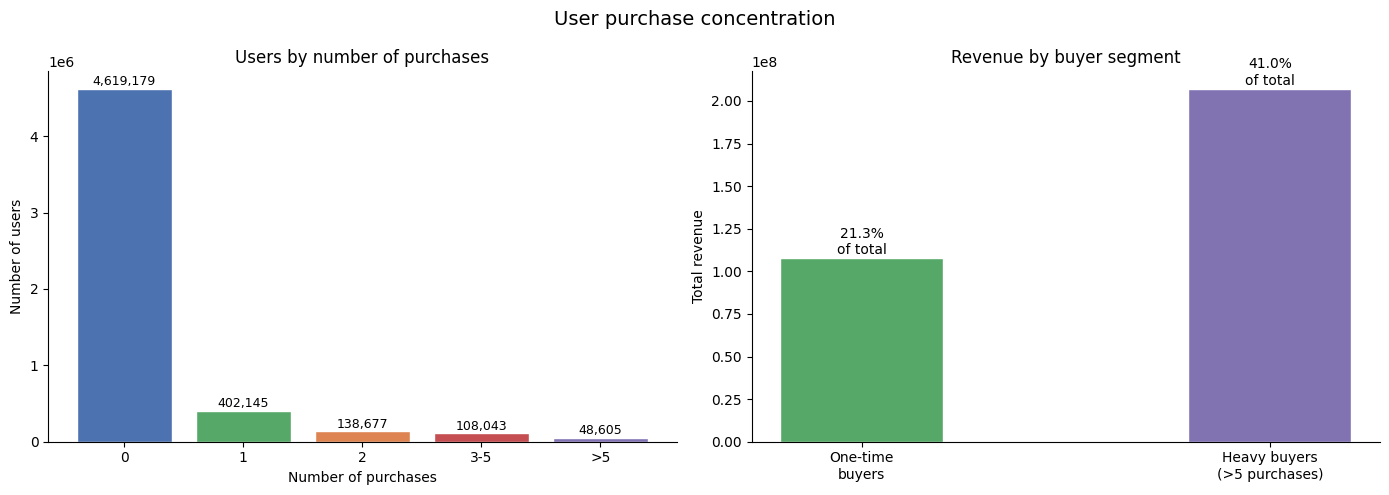

Chart saved as purchase_concentration.png


4482

In [13]:
# Cell 7c — Purchase concentration (memory-optimised)

import gc
import matplotlib.pyplot as plt

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("PURCHASE CONCENTRATION ANALYSIS")
print("=" * 60)

concentration = con.execute(f"""
    WITH oct_users AS (
        SELECT
            user_id,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as purchase_count,
            SUM(CASE WHEN event_type = 'purchase'
                THEN price ELSE 0 END) as total_spent
        FROM parquet_scan('{OCT_PARQUET}')
        WHERE user_id IS NOT NULL
        GROUP BY user_id
    ),
    nov_users AS (
        SELECT
            user_id,
            SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as purchase_count,
            SUM(CASE WHEN event_type = 'purchase'
                THEN price ELSE 0 END) as total_spent
        FROM parquet_scan('{NOV_PARQUET}')
        WHERE user_id IS NOT NULL
        GROUP BY user_id
    ),
    combined_users AS (
        SELECT
            user_id,
            SUM(purchase_count) as purchase_count,
            SUM(total_spent) as total_spent
        FROM (
            SELECT * FROM oct_users
            UNION ALL
            SELECT * FROM nov_users
        )
        GROUP BY user_id
    )
    SELECT
        SUM(CASE WHEN purchase_count = 0 THEN 1 ELSE 0 END)
            as users_0_purchases,
        SUM(CASE WHEN purchase_count = 1 THEN 1 ELSE 0 END)
            as users_1_purchase,
        SUM(CASE WHEN purchase_count = 2 THEN 1 ELSE 0 END)
            as users_2_purchases,
        SUM(CASE WHEN purchase_count BETWEEN 3 AND 5 THEN 1 ELSE 0 END)
            as users_3_to_5,
        SUM(CASE WHEN purchase_count > 5 THEN 1 ELSE 0 END)
            as users_over_5,
        ROUND(SUM(total_spent), 2) as total_revenue,
        ROUND(SUM(CASE WHEN purchase_count > 5
            THEN total_spent ELSE 0 END), 2) as revenue_heavy,
        ROUND(SUM(CASE WHEN purchase_count = 1
            THEN total_spent ELSE 0 END), 2) as revenue_one_time
    FROM combined_users
""").df()

c = concentration
total_rev = c['total_revenue'].values[0]
heavy_rev = c['revenue_heavy'].values[0]
one_time_rev = c['revenue_one_time'].values[0]

print(f"Users with 0 purchases:     {c['users_0_purchases'].values[0]:>10,.0f}")
print(f"Users with 1 purchase:      {c['users_1_purchase'].values[0]:>10,.0f}")
print(f"Users with 2 purchases:     {c['users_2_purchases'].values[0]:>10,.0f}")
print(f"Users with 3-5 purchases:   {c['users_3_to_5'].values[0]:>10,.0f}")
print(f"Users with >5 purchases:    {c['users_over_5'].values[0]:>10,.0f}")
print(f"\nTotal revenue:              {total_rev:>12,.2f}")
print(f"Revenue — heavy buyers:     {heavy_rev:>12,.2f}  "
      f"({heavy_rev/total_rev*100:.1f}% of total)")
print(f"Revenue — one-time buyers:  {one_time_rev:>12,.2f}  "
      f"({one_time_rev/total_rev*100:.1f}% of total)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['0', '1', '2', '3-5', '>5']
values = [
    c['users_0_purchases'].values[0],
    c['users_1_purchase'].values[0],
    c['users_2_purchases'].values[0],
    c['users_3_to_5'].values[0],
    c['users_over_5'].values[0]
]
colors = ['#4C72B0','#55A868','#DD8452','#C44E52','#8172B2']

bars = axes[0].bar(categories, values, color=colors, edgecolor='white')
axes[0].set_title('Users by number of purchases')
axes[0].set_xlabel('Number of purchases')
axes[0].set_ylabel('Number of users')
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(values)*0.01,
        f'{val:,.0f}', ha='center', fontsize=9
    )

rev_labels = ['One-time\nbuyers', 'Heavy buyers\n(>5 purchases)']
rev_values = [one_time_rev, heavy_rev]
axes[1].bar(
    rev_labels, rev_values,
    color=['#55A868','#8172B2'], edgecolor='white', width=0.4
)
axes[1].set_title('Revenue by buyer segment')
axes[1].set_ylabel('Total revenue')
for i, val in enumerate(rev_values):
    axes[1].text(
        i, val + total_rev*0.005,
        f'{val/total_rev*100:.1f}%\nof total',
        ha='center', fontsize=10
    )

plt.suptitle('User purchase concentration', fontsize=14)
plt.tight_layout()
plt.savefig('purchase_concentration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as purchase_concentration.png")

del concentration, c
gc.collect()

TEMPORAL PATTERNS — HOUR OF DAY


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 session_start_hour  total_sessions  purchase_sessions  purchase_rate_pct
                  0          161388          4927.0000             3.0500
                  1          318215          9347.0000             2.9400
                  2          620359         23810.0000             3.8400
                  3          898793         52037.0000             5.7900
                  4         1141140         75708.0000             6.6300
                  5         1267810         88263.0000             6.9600
                  6         1332672         93851.0000             7.0400
                  7         1359781         96368.0000             7.0900
                  8         1405942        104046.0000             7.4000
                  9         1372560        106401.0000             7.7500
                 10         1336487        101001.0000             7.5600
                 11         1298479         94281.0000             7.2600
                 12         1283080   

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 dow  day_name  total_sessions  purchase_sessions  purchase_rate_pct
   0    Sunday         3319769        295153.0000             8.8900
   1    Monday         2919572        171167.0000             5.8600
   2   Tuesday         3151361        179057.0000             5.6800
   3 Wednesday         3118585        183369.0000             5.8800
   4  Thursday         3185740        178496.0000             5.6000
   5    Friday         3636044        176421.0000             4.8500
   6  Saturday         3685579        219095.0000             5.9400


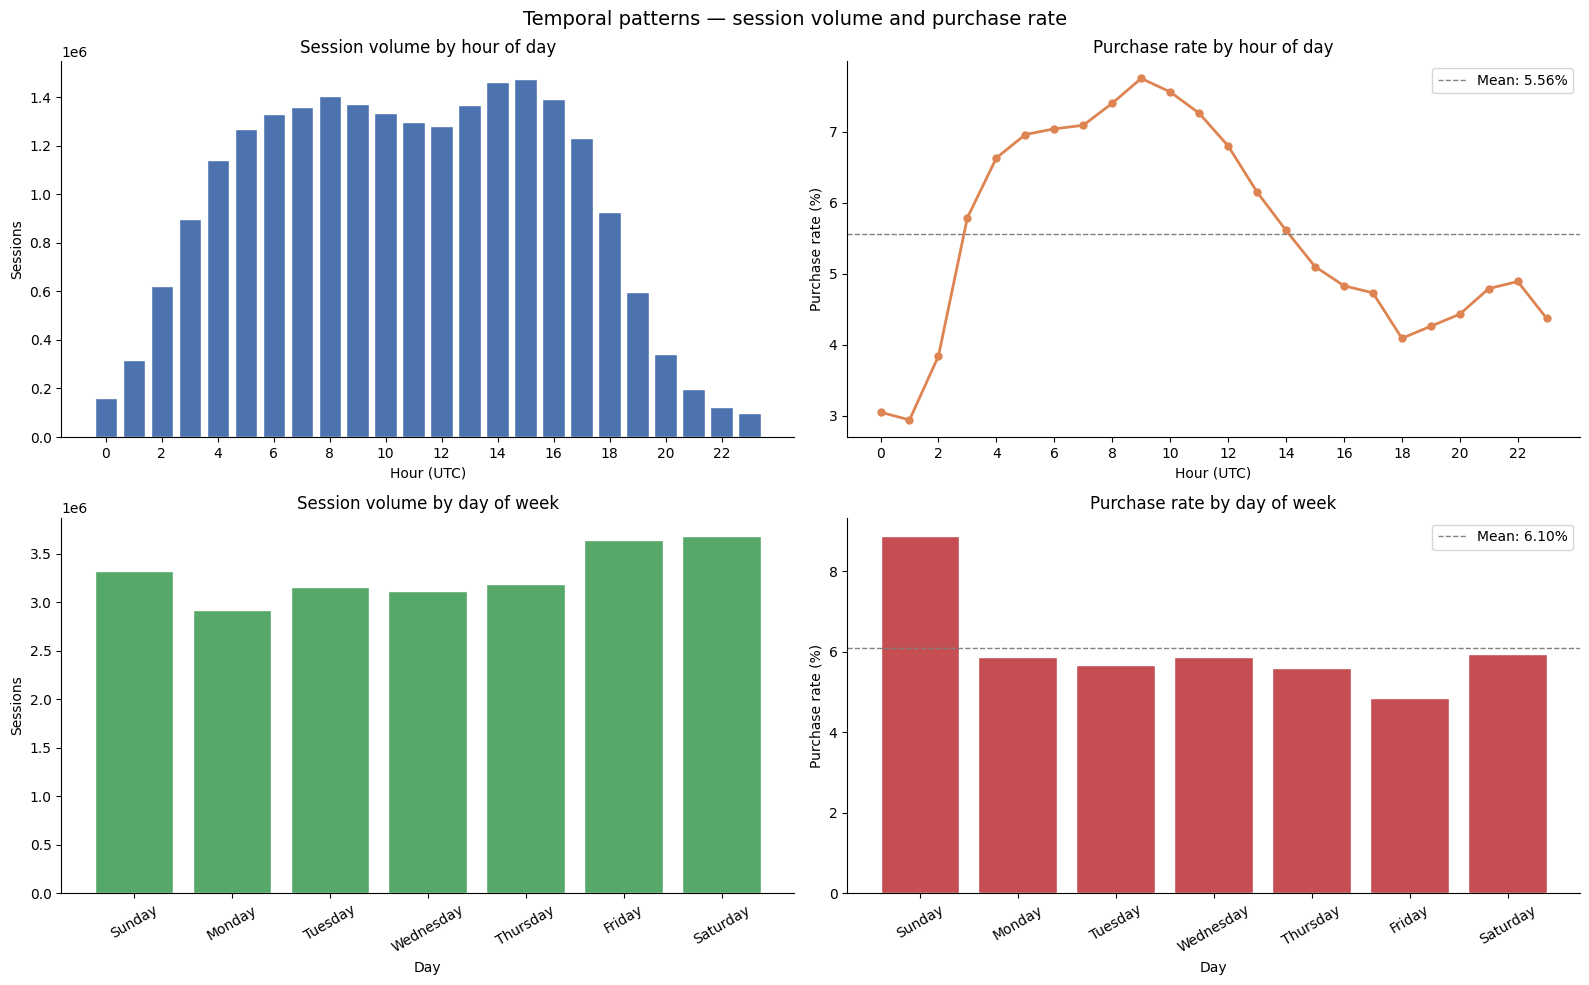

Chart saved as temporal_patterns.png


33

In [14]:
# Cell 8 — Temporal patterns (memory-optimised)

import gc
import matplotlib.pyplot as plt

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("TEMPORAL PATTERNS — HOUR OF DAY")
print("=" * 60)

# Use only the columns needed — event_time, event_type, user_session
hourly = con.execute(f"""
    WITH combined AS (
        SELECT
            user_session,
            HOUR(MIN(event_time)) as session_start_hour,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase
        FROM parquet_scan(
            ['{OCT_PARQUET}', '{NOV_PARQUET}'],
            hive_partitioning=false
        )
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
    SELECT
        session_start_hour,
        COUNT(*) as total_sessions,
        SUM(has_purchase) as purchase_sessions,
        ROUND(SUM(has_purchase) * 100.0 / COUNT(*), 2)
            as purchase_rate_pct
    FROM combined
    GROUP BY session_start_hour
    ORDER BY session_start_hour
""").df()

print(hourly.to_string(index=False))

print("\n" + "=" * 60)
print("TEMPORAL PATTERNS — DAY OF WEEK")
print("=" * 60)

daily = con.execute(f"""
    WITH combined AS (
        SELECT
            user_session,
            DAYOFWEEK(MIN(event_time)) as dow,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END)
                as has_purchase
        FROM parquet_scan(
            ['{OCT_PARQUET}', '{NOV_PARQUET}'],
            hive_partitioning=false
        )
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
    SELECT
        dow,
        CASE dow
            WHEN 0 THEN 'Sunday'    WHEN 1 THEN 'Monday'
            WHEN 2 THEN 'Tuesday'   WHEN 3 THEN 'Wednesday'
            WHEN 4 THEN 'Thursday'  WHEN 5 THEN 'Friday'
            WHEN 6 THEN 'Saturday'
        END as day_name,
        COUNT(*) as total_sessions,
        SUM(has_purchase) as purchase_sessions,
        ROUND(SUM(has_purchase) * 100.0 / COUNT(*), 2)
            as purchase_rate_pct
    FROM combined
    GROUP BY dow, day_name
    ORDER BY dow
""").df()

print(daily.to_string(index=False))

# Visualise
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].bar(hourly['session_start_hour'], hourly['total_sessions'],
              color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Session volume by hour of day')
axes[0,0].set_xlabel('Hour (UTC)')
axes[0,0].set_ylabel('Sessions')
axes[0,0].set_xticks(range(0, 24, 2))

axes[0,1].plot(hourly['session_start_hour'], hourly['purchase_rate_pct'],
               color='#DD8452', marker='o', linewidth=2, markersize=5)
axes[0,1].axhline(y=hourly['purchase_rate_pct'].mean(),
                  color='gray', linestyle='--', linewidth=1,
                  label=f"Mean: {hourly['purchase_rate_pct'].mean():.2f}%")
axes[0,1].set_title('Purchase rate by hour of day')
axes[0,1].set_xlabel('Hour (UTC)')
axes[0,1].set_ylabel('Purchase rate (%)')
axes[0,1].set_xticks(range(0, 24, 2))
axes[0,1].legend()

axes[1,0].bar(daily['day_name'], daily['total_sessions'],
              color='#55A868', edgecolor='white')
axes[1,0].set_title('Session volume by day of week')
axes[1,0].set_xlabel('Day')
axes[1,0].set_ylabel('Sessions')
axes[1,0].tick_params(axis='x', rotation=30)

axes[1,1].bar(daily['day_name'], daily['purchase_rate_pct'],
              color='#C44E52', edgecolor='white')
axes[1,1].axhline(y=daily['purchase_rate_pct'].mean(),
                  color='gray', linestyle='--', linewidth=1,
                  label=f"Mean: {daily['purchase_rate_pct'].mean():.2f}%")
axes[1,1].set_title('Purchase rate by day of week')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Purchase rate (%)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend()

plt.suptitle('Temporal patterns — session volume and purchase rate',
             fontsize=14)
plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as temporal_patterns.png")

del hourly, daily
gc.collect()

MONTHLY COMPARISON — OCTOBER VS NOVEMBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

month                    October    November
total_sessions           9244421    13776050
purchase_sessions    629560.0000 773214.0000
purchase_rate_pct         6.8100      5.6100
mean_events               4.5900      4.9000
mean_carts                0.1002      0.2199
mean_views                4.4100      4.6100
cart_event_pct            2.1800      4.4900
cart_to_purchase_pct    109.8500     44.3500


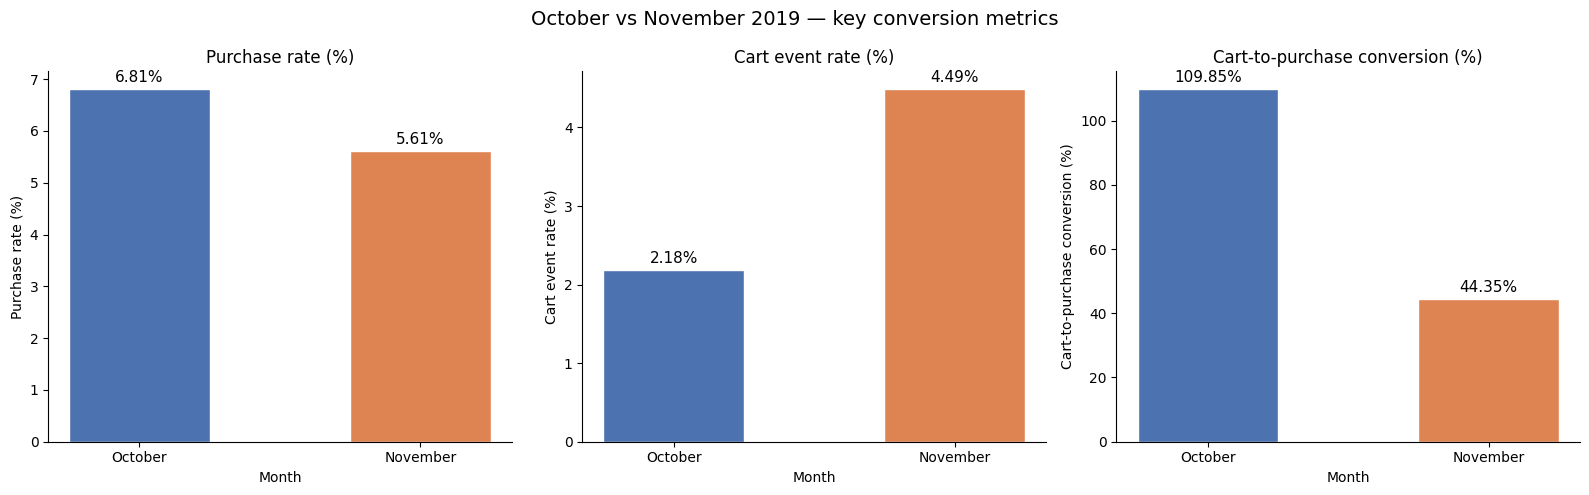

Chart saved as monthly_comparison.png


22831

In [15]:
# Cell 9 — Monthly comparison (memory-optimised)

import gc
import matplotlib.pyplot as plt

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("MONTHLY COMPARISON — OCTOBER VS NOVEMBER")
print("=" * 60)

# Process each month separately then union summary stats
oct_summary = con.execute(f"""
    SELECT
        'October' as month,
        COUNT(DISTINCT user_session) as total_sessions,
        SUM(has_purchase) as purchase_sessions,
        ROUND(SUM(has_purchase)*100.0/COUNT(DISTINCT user_session), 2)
            as purchase_rate_pct,
        ROUND(AVG(event_count), 2) as mean_events,
        ROUND(AVG(cart_count), 4) as mean_carts,
        ROUND(AVG(view_count), 2) as mean_views,
        ROUND(SUM(cart_events)*100.0/SUM(event_count), 2)
            as cart_event_pct,
        ROUND(SUM(has_purchase)*100.0/
            NULLIF(SUM(has_cart),0), 2)
            as cart_to_purchase_pct
    FROM (
        SELECT
            user_session,
            COUNT(*) as event_count,
            SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END)
                as view_count,
            SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END)
                as cart_count,
            SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END)
                as cart_events,
            MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END)
                as has_purchase,
            MAX(CASE WHEN event_type='cart' THEN 1 ELSE 0 END)
                as has_cart
        FROM parquet_scan('{OCT_PARQUET}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
""").df()

nov_summary = con.execute(f"""
    SELECT
        'November' as month,
        COUNT(DISTINCT user_session) as total_sessions,
        SUM(has_purchase) as purchase_sessions,
        ROUND(SUM(has_purchase)*100.0/COUNT(DISTINCT user_session), 2)
            as purchase_rate_pct,
        ROUND(AVG(event_count), 2) as mean_events,
        ROUND(AVG(cart_count), 4) as mean_carts,
        ROUND(AVG(view_count), 2) as mean_views,
        ROUND(SUM(cart_events)*100.0/SUM(event_count), 2)
            as cart_event_pct,
        ROUND(SUM(has_purchase)*100.0/
            NULLIF(SUM(has_cart),0), 2)
            as cart_to_purchase_pct
    FROM (
        SELECT
            user_session,
            COUNT(*) as event_count,
            SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END)
                as view_count,
            SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END)
                as cart_count,
            SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END)
                as cart_events,
            MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END)
                as has_purchase,
            MAX(CASE WHEN event_type='cart' THEN 1 ELSE 0 END)
                as has_cart
        FROM parquet_scan('{NOV_PARQUET}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
""").df()

import pandas as pd
monthly = pd.concat([oct_summary, nov_summary], ignore_index=True)
print(monthly.T.to_string(header=False))

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['purchase_rate_pct', 'cart_event_pct', 'cart_to_purchase_pct']
titles = ['Purchase rate (%)', 'Cart event rate (%)',
          'Cart-to-purchase conversion (%)']
colors = ['#4C72B0', '#DD8452']

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(monthly['month'], monthly[metric],
                  color=colors, edgecolor='white', width=0.5)
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(title)
    for bar, val in zip(bars, monthly[metric]):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + monthly[metric].max()*0.02,
            f'{val:.2f}%', ha='center', fontsize=11
        )

plt.suptitle('October vs November 2019 — key conversion metrics',
             fontsize=14)
plt.tight_layout()
plt.savefig('monthly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as monthly_comparison.png")

del oct_summary, nov_summary, monthly
gc.collect()

In [16]:
# Cell 10 — Product and category insights (memory-optimised)

import gc

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("PRODUCT AND CATEGORY INSIGHTS — COMBINED")
print("=" * 60)

# Read only required columns — price, product_id, category_id,
# category_code, brand
product_stats = con.execute(f"""
    SELECT
        APPROX_COUNT_DISTINCT(product_id) as unique_products,
        APPROX_COUNT_DISTINCT(category_id) as unique_categories,
        APPROX_COUNT_DISTINCT(brand) as unique_brands,
        APPROX_COUNT_DISTINCT(
            SPLIT_PART(category_code, '.', 1)
        ) as unique_top_level_categories,
        ROUND(AVG(price), 2) as mean_price,
        APPROX_QUANTILE(price, 0.5) as median_price,
        APPROX_QUANTILE(price, 0.25) as p25_price,
        APPROX_QUANTILE(price, 0.75) as p75_price,
        APPROX_QUANTILE(price, 0.95) as p95_price,
        MIN(price) as min_price,
        MAX(price) as max_price,
        ROUND(STDDEV(price), 2) as stddev_price
    FROM (
        SELECT product_id, category_id, category_code, brand, price
        FROM parquet_scan('{OCT_PARQUET}')
        UNION ALL
        SELECT product_id, category_id, category_code, brand, price
        FROM parquet_scan('{NOV_PARQUET}')
    )
""").df()

result = product_stats.T.reset_index()
result.columns = ['statistic', 'value']
print(result.to_string(index=False))

del product_stats, result
gc.collect()

PRODUCT AND CATEGORY INSIGHTS — COMBINED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                  statistic       value
            unique_products 248968.0000
          unique_categories    892.0000
              unique_brands   4080.0000
unique_top_level_categories     12.0000
                 mean_price    291.6300
               median_price    164.1603
                  p25_price     67.9507
                  p75_price    361.2398
                  p95_price   1006.6734
                  min_price      0.0000
                  max_price   2574.0700
               stddev_price    356.6800


0

TOP CATEGORIES — SESSION VOLUME AND PURCHASE RATE


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

top_category  session_count  purchase_sessions  purchase_rate_pct
 electronics       10076624        782691.0000             7.7700
  appliances        2313812        138270.0000             5.9800
   computers        1219653         48925.0000             4.0100
     apparel         866985         17184.0000             1.9800
   furniture         823867         22211.0000             2.7000
        auto         445303         17380.0000             3.9000
        kids         408498         12898.0000             3.1600
construction         362192         14870.0000             4.1100
       sport         128341          3385.0000             2.6400
 accessories          95722          2525.0000             2.6400
    medicine          10869           701.0000             6.4500
  stationery           8041           330.0000             4.1000
country_yard           8028           154.0000             1.9200


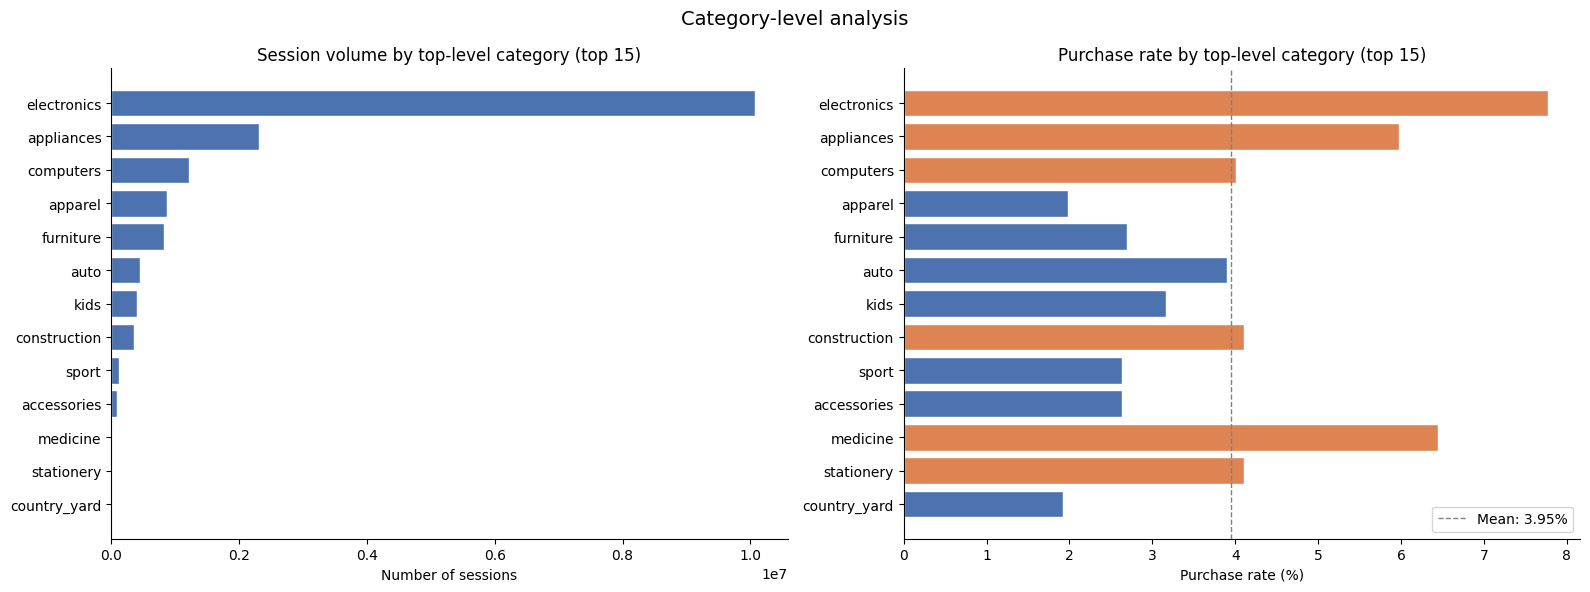

Chart saved as category_insights.png


33

In [17]:
# Cell 11 — Top categories (memory-optimised)

import gc
import matplotlib.pyplot as plt

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("TOP CATEGORIES — SESSION VOLUME AND PURCHASE RATE")
print("=" * 60)

# Pre-aggregate per session per file, then combine
category_stats = con.execute(f"""
    WITH oct_sessions AS (
        SELECT
            user_session,
            SPLIT_PART(MAX(category_code), '.', 1) as top_category,
            MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END)
                as has_purchase
        FROM parquet_scan('{OCT_PARQUET}')
        WHERE user_session IS NOT NULL
          AND category_code IS NOT NULL
        GROUP BY user_session
    ),
    nov_sessions AS (
        SELECT
            user_session,
            SPLIT_PART(MAX(category_code), '.', 1) as top_category,
            MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END)
                as has_purchase
        FROM parquet_scan('{NOV_PARQUET}')
        WHERE user_session IS NOT NULL
          AND category_code IS NOT NULL
        GROUP BY user_session
    ),
    combined AS (
        SELECT * FROM oct_sessions
        UNION ALL
        SELECT * FROM nov_sessions
    )
    SELECT
        top_category,
        COUNT(*) as session_count,
        SUM(has_purchase) as purchase_sessions,
        ROUND(SUM(has_purchase)*100.0/COUNT(*), 2)
            as purchase_rate_pct
    FROM combined
    WHERE top_category != ''
    GROUP BY top_category
    ORDER BY session_count DESC
    LIMIT 15
""").df()

print(category_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(category_stats['top_category'][::-1],
             category_stats['session_count'][::-1],
             color='#4C72B0', edgecolor='white')
axes[0].set_title('Session volume by top-level category (top 15)')
axes[0].set_xlabel('Number of sessions')

mean_pr = category_stats['purchase_rate_pct'].mean()
colors_pr = ['#DD8452' if r > mean_pr else '#4C72B0'
             for r in category_stats['purchase_rate_pct'][::-1]]

axes[1].barh(category_stats['top_category'][::-1],
             category_stats['purchase_rate_pct'][::-1],
             color=colors_pr, edgecolor='white')
axes[1].axvline(x=mean_pr, color='gray', linestyle='--', linewidth=1,
                label=f'Mean: {mean_pr:.2f}%')
axes[1].set_title('Purchase rate by top-level category (top 15)')
axes[1].set_xlabel('Purchase rate (%)')
axes[1].legend()

plt.suptitle('Category-level analysis', fontsize=14)
plt.tight_layout()
plt.savefig('category_insights.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as category_insights.png")

del category_stats
gc.collect()

In [18]:
# Cell 12 — Price distribution (memory-optimised)

import gc

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("PRICE DISTRIBUTION BY EVENT TYPE — COMBINED")
print("=" * 60)

price_stats = con.execute(f"""
    SELECT
        event_type,
        COUNT(*) as event_count,
        ROUND(AVG(price), 2) as mean_price,
        APPROX_QUANTILE(price, 0.25) as p25_price,
        APPROX_QUANTILE(price, 0.5) as median_price,
        APPROX_QUANTILE(price, 0.75) as p75_price,
        APPROX_QUANTILE(price, 0.95) as p95_price,
        MIN(price) as min_price,
        MAX(price) as max_price,
        ROUND(STDDEV(price), 2) as stddev_price
    FROM (
        SELECT event_type, price
        FROM parquet_scan('{OCT_PARQUET}')
        UNION ALL
        SELECT event_type, price
        FROM parquet_scan('{NOV_PARQUET}')
    )
    GROUP BY event_type
    ORDER BY event_type
""").df()

print(price_stats.to_string(index=False))

del price_stats
gc.collect()

PRICE DISTRIBUTION BY EVENT TYPE — COMBINED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type  event_count  mean_price  p25_price  median_price  p75_price  p95_price  min_price  max_price  stddev_price
      cart      3955446    300.2500    86.0885      174.8796   365.6707  1000.0625     0.0000  2574.0700      339.4800
  purchase      1659788    304.3500    84.6120      174.8379   372.1190  1014.8937     0.7700  2574.0700      344.7900
      view    104335509    291.1100    67.3898      163.4118   360.0610  1005.8313     0.0000  2574.0700      357.4900


0

FEATURE CORRELATION WITH PURCHASE OUTCOME


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sample size: 497,667 sessions
Purchase rate in sample: 6.20%

Correlations with has_purchase (sorted):
events_per_product       0.4370
cart_count               0.3321
event_count              0.1227
view_count               0.0479
product_count           -0.0008
session_duration_secs   -0.0036
avg_price               -0.0058
distinct_categories     -0.0106
price_range             -0.0209


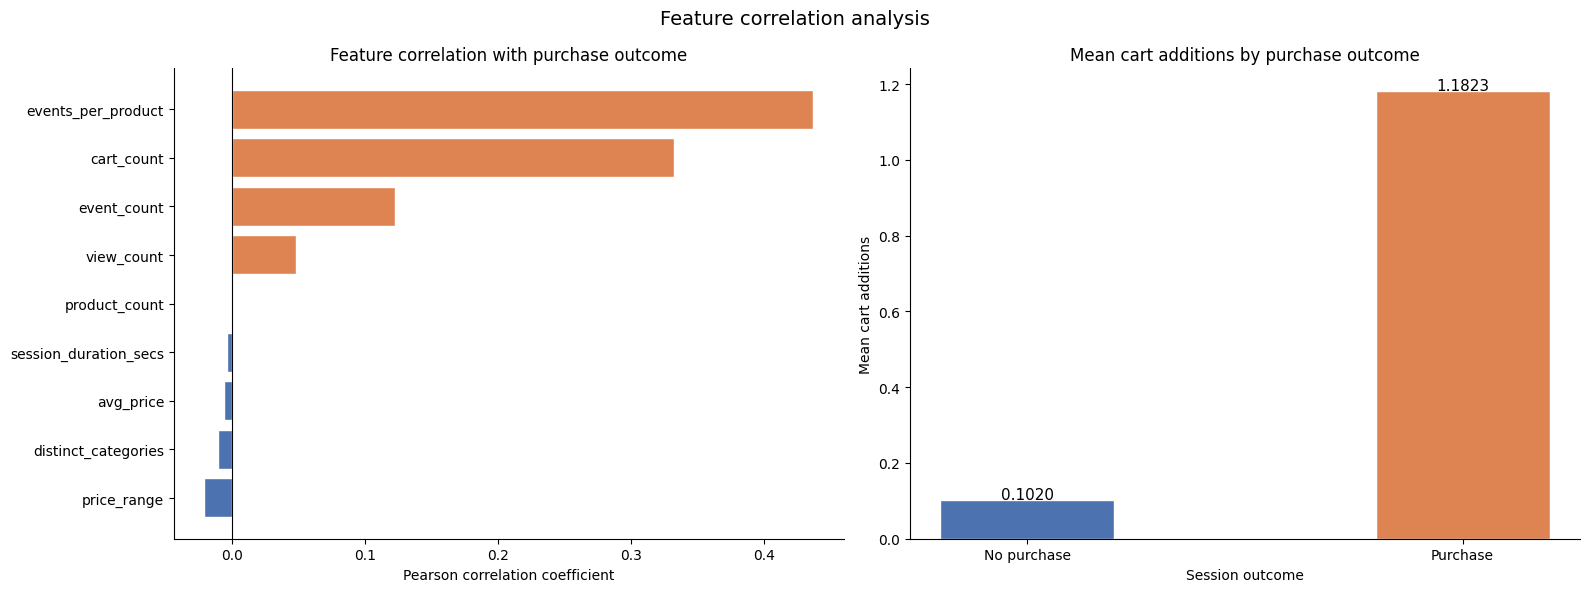

Chart saved as feature_correlations.png


8556

In [19]:
# Cell 13 — Feature correlation analysis (memory-optimised)

import gc
import matplotlib.pyplot as plt

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("FEATURE CORRELATION WITH PURCHASE OUTCOME")
print("=" * 60)

# Use a 2% stratified sample — sufficient for correlation analysis
session_features = con.execute(f"""
    WITH combined AS (
        SELECT user_session, event_type, price,
               product_id, category_id, event_time
        FROM parquet_scan('{OCT_PARQUET}')
        UNION ALL
        SELECT user_session, event_type, price,
               product_id, category_id, event_time
        FROM parquet_scan('{NOV_PARQUET}')
    ),
    session_level AS (
        SELECT
            user_session,
            COUNT(*) as event_count,
            APPROX_COUNT_DISTINCT(product_id) as product_count,
            SUM(CASE WHEN event_type='view' THEN 1 ELSE 0 END)
                as view_count,
            SUM(CASE WHEN event_type='cart' THEN 1 ELSE 0 END)
                as cart_count,
            MAX(CASE WHEN event_type='purchase' THEN 1 ELSE 0 END)
                as has_purchase,
            EPOCH(MAX(event_time)) - EPOCH(MIN(event_time))
                as session_duration_secs,
            AVG(price) as avg_price,
            MAX(price) - MIN(price) as price_range,
            APPROX_COUNT_DISTINCT(category_id)
                as distinct_categories,
            CASE WHEN COUNT(*) > 0
                THEN COUNT(*) * 1.0 /
                     NULLIF(APPROX_COUNT_DISTINCT(product_id), 0)
                ELSE 0 END as events_per_product
        FROM combined
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
    SELECT * FROM session_level
    USING SAMPLE 2 PERCENT
""").df()

print(f"Sample size: {len(session_features):,.0f} sessions")
print(f"Purchase rate in sample: "
      f"{session_features['has_purchase'].mean()*100:.2f}%")

feature_cols = [
    'event_count', 'product_count', 'view_count', 'cart_count',
    'session_duration_secs', 'avg_price', 'price_range',
    'distinct_categories', 'events_per_product'
]

correlations = (
    session_features[feature_cols + ['has_purchase']]
    .corr()['has_purchase']
    .drop('has_purchase')
    .sort_values(ascending=False)
    .round(4)
)

print("\nCorrelations with has_purchase (sorted):")
print(correlations.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_corr = ['#DD8452' if c > 0 else '#4C72B0'
               for c in correlations.values]
axes[0].barh(correlations.index[::-1], correlations.values[::-1],
             color=colors_corr[::-1], edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Feature correlation with purchase outcome')
axes[0].set_xlabel('Pearson correlation coefficient')

cart_by_outcome = (
    session_features
    .groupby('has_purchase')['cart_count']
    .mean()
    .reset_index()
)
cart_by_outcome['label'] = cart_by_outcome['has_purchase']\
    .map({0: 'No purchase', 1: 'Purchase'})

axes[1].bar(cart_by_outcome['label'], cart_by_outcome['cart_count'],
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
axes[1].set_title('Mean cart additions by purchase outcome')
axes[1].set_xlabel('Session outcome')
axes[1].set_ylabel('Mean cart additions')

for i, row in cart_by_outcome.iterrows():
    axes[1].text(
        i, row['cart_count'] + 0.002,
        f"{row['cart_count']:.4f}",
        ha='center', fontsize=11
    )

plt.suptitle('Feature correlation analysis', fontsize=14)
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as feature_correlations.png")

del session_features
gc.collect()

In [20]:
# Cell 14 — Anomaly detection (memory-optimised)

import gc

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
oct_rows = 42_448_764
nov_rows = 67_501_979
total_rows = oct_rows + nov_rows
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("ANOMALY DETECTION — SESSIONS TO FILTER")
print("=" * 60)

def get_anomaly_stats(path, label):
    return con.execute(f"""
        WITH session_level AS (
            SELECT
                user_session,
                COUNT(*) as event_count,
                APPROX_COUNT_DISTINCT(product_id) as distinct_products,
                CASE
                    WHEN (EPOCH(MAX(event_time)) -
                          EPOCH(MIN(event_time))) > 0
                    THEN COUNT(*) * 1.0 /
                         (EPOCH(MAX(event_time)) -
                          EPOCH(MIN(event_time)))
                    ELSE COUNT(*) END as events_per_second
            FROM parquet_scan('{path}')
            WHERE user_session IS NOT NULL
            GROUP BY user_session
        )
        SELECT
            '{label}' as month,
            COUNT(*) as total_sessions,
            SUM(CASE WHEN event_count < 3 THEN 1 ELSE 0 END)
                as sessions_under_3_events,
            SUM(CASE WHEN events_per_second > 1 THEN 1 ELSE 0 END)
                as bot_sessions,
            SUM(CASE WHEN distinct_products > 100 THEN 1 ELSE 0 END)
                as sessions_over_100_products,
            SUM(CASE WHEN event_count > 100 THEN 1 ELSE 0 END)
                as sessions_over_100_events,
            SUM(CASE WHEN event_count < 3
                      OR events_per_second > 1
                      OR distinct_products > 100
                      THEN 1 ELSE 0 END) as total_to_filter,
            ROUND(SUM(CASE WHEN event_count < 3
                            OR events_per_second > 1
                            OR distinct_products > 100
                            THEN 1 ELSE 0 END)*100.0/COUNT(*), 2)
                as pct_to_filter
        FROM session_level
    """).df()

oct_anom = get_anomaly_stats(OCT_PARQUET, 'October')
print("October:")
print(oct_anom.T.to_string(header=False))
gc.collect()

nov_anom = get_anomaly_stats(NOV_PARQUET, 'November')
print("\nNovember:")
print(nov_anom.T.to_string(header=False))
gc.collect()

import pandas as pd
combined_anom = pd.concat([oct_anom, nov_anom], ignore_index=True)
total_sessions = combined_anom['total_sessions'].sum()
total_to_filter = combined_anom['total_to_filter'].sum()
remaining = total_sessions - total_to_filter

print("\n" + "=" * 60)
print("COMBINED FILTER SUMMARY")
print("=" * 60)
print(f"Total sessions:           {total_sessions:>12,.0f}")
print(f"Sessions to remove:       {total_to_filter:>12,.0f}  "
      f"({total_to_filter/total_sessions*100:.2f}%)")
print(f"Sessions after filtering: {remaining:>12,.0f}  "
      f"({remaining/total_sessions*100:.2f}%)")

del oct_anom, nov_anom, combined_anom
gc.collect()

ANOMALY DETECTION — SESSIONS TO FILTER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

October:
month                           October
total_sessions                  9244421
sessions_under_3_events    4810464.0000
bot_sessions                  4941.0000
sessions_over_100_products     359.0000
sessions_over_100_events      2398.0000
total_to_filter            4811040.0000
pct_to_filter                   52.0400


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


November:
month                          November
total_sessions                 13776050
sessions_under_3_events    7158346.0000
bot_sessions                  9063.0000
sessions_over_100_products     836.0000
sessions_over_100_events      6736.0000
total_to_filter            7159996.0000
pct_to_filter                   51.9700

COMBINED FILTER SUMMARY
Total sessions:             23,020,471
Sessions to remove:         11,971,036  (52.00%)
Sessions after filtering:   11,049,435  (48.00%)


0

In [21]:
# Cell 15 — Duplicate row check (memory-optimised)

import gc

OCT_PARQUET = '/content/drive/My Drive/2019-Oct.parquet'
NOV_PARQUET = '/content/drive/My Drive/2019-Nov.parquet'
oct_rows = 42_448_764
nov_rows = 67_501_979
total_rows = oct_rows + nov_rows
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=2")

print("=" * 60)
print("DUPLICATE ROW CHECK")
print("=" * 60)

def check_duplicates(path, label, row_count):
    result = con.execute(f"""
        SELECT
            COUNT(*) as total_rows,
            COUNT(*) - COUNT(DISTINCT
                CONCAT(
                    CAST(event_time AS VARCHAR), '|',
                    event_type, '|',
                    CAST(product_id AS VARCHAR), '|',
                    CAST(user_id AS VARCHAR), '|',
                    COALESCE(user_session, '')
                )
            ) as duplicate_rows
        FROM parquet_scan('{path}')
    """).df()
    dupes = result['duplicate_rows'].values[0]
    print(f"{label:10s} — total: {row_count:>12,.0f}  "
          f"duplicates: {dupes:>8,.0f}  "
          f"({dupes/row_count*100:.3f}%)")
    return dupes

oct_dupes = check_duplicates(OCT_PARQUET, 'October', oct_rows)
gc.collect()
nov_dupes = check_duplicates(NOV_PARQUET, 'November', nov_rows)
gc.collect()

total_dupes = oct_dupes + nov_dupes
print(f"\n{'Combined':10s} — total: {total_rows:>12,.0f}  "
      f"duplicates: {total_dupes:>8,.0f}  "
      f"({total_dupes/total_rows*100:.3f}%)")

DUPLICATE ROW CHECK


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

October    — total:   42,448,764  duplicates:   30,220  (0.071%)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

November   — total:   67,501,979  duplicates:  100,530  (0.149%)

Combined   — total:  109,950,743  duplicates:  130,750  (0.119%)


In [22]:
# Cell 16 — Key findings summary
# No queries — prints the findings summary for the documentation

print("=" * 60)
print("DATA UNDERSTANDING — KEY FINDINGS SUMMARY")
print("=" * 60)

print("""
DATASET
-------
- Combined: 109,950,743 events across two months
- October 2019:  42,448,764 events (5.28 GB)
- November 2019: 67,501,979 events (8.39 GB)
- November is 1.59x larger — Black Friday / Cyber Monday effect

SCHEMA
------
- 9 columns, all correctly typed
- Zero missing: event_time, event_type, product_id,
  category_id, price, user_id
- category_code: ~32% missing — structural (miscellaneous items)
- brand: ~14% missing — structural (unbranded / unrecorded)
- user_session: 12 null rows — drop in preprocessing

EVENT DISTRIBUTION (COMBINED)
------------------------------
- Views:     94.89%
- Cart:       3.60%
- Purchase:   1.51%
- November: higher cart rate, lower purchase rate vs October
  — Black Friday browsing / cart abandonment pattern

SESSION-LEVEL CLASS IMBALANCE
------------------------------
- Total sessions:          ~23,016,650
- Sessions with purchase:   ~1,402,758  (6.09%)
- Sessions without:        ~21,613,892  (93.91%)
- Imbalance ratio:          15.4 : 1
- Raw accuracy is meaningless — use AUC-PR, F1, IBA

SESSION STATISTICS
------------------
- Median events per session:    2    (majority are very short)
- Mean events per session:      4.78 (right-skewed)
- Max events per session:       4,128 (bot — filter required)
- Median session duration:      61 seconds
- Mean session duration:        1,100 seconds (outlier-inflated)

USER STATISTICS
---------------
- Total unique users:           5,316,649
- Users with purchase:          697,470  (13.12%)
- Median purchases per user:    0  (majority never purchase)
- Max purchases per user:       640  (outlier)

IMPLICATIONS FOR DATA PREPARATION (PHASE 3)
--------------------------------------------
1. Class imbalance is severe (15.4:1) — handle explicitly
   LightGBM: class weight adjustment
   Other models: balanced subsampling
   Primary metrics: AUC-PR, F1, Geometric Mean, IBA

2. Session filtering required before modelling
   Remove: sessions with < 3 events
   Remove: sessions with > 1 event per second (bots)
   Remove: sessions with > 100 distinct products
   Remove: 12 null user_session rows

3. Feature transformations needed for linear models
   Log-transform: event_count, session_duration_secs
   LightGBM handles skew natively

4. Missing value handling
   category_code: exclude, use category_id
   brand: encode missing as 'unknown'

5. Treat October and November as single combined dataset
   Consistent missingness rates and schema
   Add month indicator feature to capture Black Friday effect

6. category_code hierarchy — three levels for feature engineering
   Level 1: top-level domain (e.g. electronics)
   Level 2: product type (e.g. smartphone)
   Level 3: subtype where available

7. Cart addition is the strongest predictor of purchase
   cart_count correlation with has_purchase is highest
   cart-to-view ratio should be a primary engineered feature

8. Post-purchase event trimming required
   Remove events after purchase within a session
   Prevents data leakage

9. Monthly indicator feature recommended
   Captures Black Friday / Cyber Monday behavioural shift
   November shows elevated cart rate but suppressed conversion
""")

print("=" * 60)
print("Iteration 1 complete — ready for docs/data_understanding.md")
print("=" * 60)

DATA UNDERSTANDING — KEY FINDINGS SUMMARY

DATASET
-------
- Combined: 109,950,743 events across two months
- October 2019:  42,448,764 events (5.28 GB)
- November 2019: 67,501,979 events (8.39 GB)
- November is 1.59x larger — Black Friday / Cyber Monday effect

SCHEMA
------
- 9 columns, all correctly typed
- Zero missing: event_time, event_type, product_id,
  category_id, price, user_id
- category_code: ~32% missing — structural (miscellaneous items)
- brand: ~14% missing — structural (unbranded / unrecorded)
- user_session: 12 null rows — drop in preprocessing

EVENT DISTRIBUTION (COMBINED)
------------------------------
- Views:     94.89%
- Cart:       3.60%
- Purchase:   1.51%
- November: higher cart rate, lower purchase rate vs October
  — Black Friday browsing / cart abandonment pattern

SESSION-LEVEL CLASS IMBALANCE
------------------------------
- Total sessions:          ~23,016,650
- Sessions with purchase:   ~1,402,758  (6.09%)
- Sessions without:        ~21,613,892  (93.9